## 0. Imports

In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
# """Installs"""

# !pip install nc-time-axis
# !pip install netCDF4 h5netcdf
# !pip install xarray
# !pip install cdsapi
# !pip install networkx geopandas osmnx igraph matplotlib
# !pip install pysal scikit-learn libpysal tobler geopandas numpy pandas networkx
# !pip install access
# !pip install transliterate


In [ ]:
"""Path handling"""

from pathlib import Path
import sys


# Ноутбук лежит в корне проекта, скрипты — в arctic_access/
module_path = str(Path.cwd() / "arctic_access")
if module_path not in sys.path:
    sys.path.insert(0, module_path)

# Патчим data_path в модулях, которые импортируют его напрямую (from ... import data_path).
# Делаем это после добавления пути в sys.path, но до первого использования.
_data_path = str(Path.cwd() / "arctic_access" / "data" / "processed") + "/"

import scripts.preprocesser.constants as _constants

_constants.data_path = _data_path

# huston импортирует data_path как локальную переменную — патчим и там
import scripts.preprocesser.huston as _huston

_huston.data_path = _data_path


In [ ]:
"""Imports"""

import matplotlib.pyplot as plt
from tqdm import tqdm
import time

from scripts.calculator.calculator_this_pipeline import make_block_scheme
from scripts.plotter.plotter_transport_mode_prob import (
    plot_transport_probability_legacy,
)
from scripts.calculator.calculator_transport_prob import get_transport_probability
from scripts.preprocesser.preprocesser import get_data
from scripts.preprocesser.gcreator import make_g, add_temp_to_g
from scripts.preprocesser.huston import call_nasa
from scripts.calculator.calculator_stat import create_agglomeration_network
from scripts.calculator.calculator_monthly_mode import create_df_modes_monthly_fixed
import scripts.model.provision as provision
from scripts.plotter.plotter_multilayer_service_network import plot_multilayer_network
from scripts.plotter.plotter_flow_sankey import create_clean_sankey
from scripts.plotter.plotter_circular_network_sankey_style import (
    plot_circular_network_sankey_style,
)
from scripts.plotter.plotter_multi_temporal_nx_plots import (
    plot_temporal_service_evolution,
    calculate_temporal_metrics,
    plot_temporal_metrics,
)
from scripts.preprocesser.constants import (
    START_YEAR,
    MONTHS_IN_YEAR,
    CONST_BASE_DEMAND,
    transport_modes,
    transport_modes_color,
    service_radius_minutes,
    transport_mode_name_mapper,
    service_list,
    threshold,
    month_order,
)


tqdm.pandas()


## 1. Transport prob chart [user-defined]

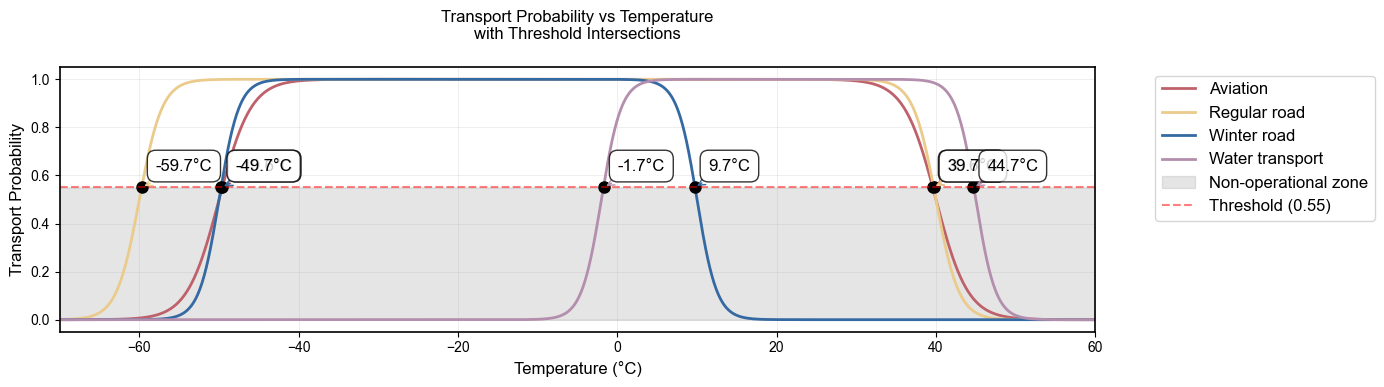

In [ ]:
threshold_temperatures = plot_transport_probability_legacy(
    transport_modes,
    transport_modes_color,
    get_transport_probability,
    threshold,
    temps=None,
    font_size=12,
)


## 2. Main calculations

In [ ]:
# Store results for each settlement and service
all_results = {}
# yakut_chuk
# yanao_kras
# mezen
# nao

data_path = "./arctic_access/data/"
settl_name_lst = ["yanao_kras"]
range_months = range(12)  # Starting Jan 1982

for SETTL_NAME in settl_name_lst:
    print("=" * 10, SETTL_NAME, "=" * 10)

    # Initialize settlement results
    all_results[SETTL_NAME] = {}
    # service_list
    for SERVICE_NAME in service_list:
        print(" " * 10, SERVICE_NAME, " " * 10)

        CLIMATE_DATA_FILE_NAME = f"df_climate_{SETTL_NAME}.csv"

        settl, df_service, transport_df, infr_df = get_data(
            data_path,
            SETTL_NAME,
            transport_mode_name_mapper,
            transport_modes,
            SERVICE_NAME,
        )
        blocks_gdf = make_block_scheme(settl, df_service, service_name=SERVICE_NAME)
        G_undirected = make_g(transport_df, transport_modes, blocks_gdf, settl)

        df_monthly_list = call_nasa(blocks_gdf, CLIMATE_DATA_FILE_NAME)
        G_undirected = add_temp_to_g(G_undirected, df_monthly_list)

        net = create_agglomeration_network(
            graph=G_undirected,
            threshold=threshold,
            probability_function=get_transport_probability,
            provision_calculator=provision.calculate_graph_provision,
        )

        net.run_all_steps(
            range_months,
            service_radius_minutes=service_radius_minutes[SETTL_NAME],
            base_demand=CONST_BASE_DEMAND,
            service_name=SERVICE_NAME,
            return_assignment=True,
        )

        # Store results for this service
        all_results[SETTL_NAME][SERVICE_NAME] = {
            "net": net,
            "stats": net.stats,
            "graphs": net.stats.graphs,
            "records": net.stats.records,
            "results": net.stats.results,
            "G_undirected": G_undirected,
        }

        # Предполагаем что индекс df_stats — это месяцы в виде `i` (0...len-1)
        df_stats = net.stats.records
        try:
            df_stats["Month"] = df_stats.index % MONTHS_IN_YEAR + 1
            df_stats["Year"] = START_YEAR + df_stats.index // MONTHS_IN_YEAR
        except Exception:
            pass

        df_modes_monthly = create_df_modes_monthly_fixed(
            G_undirected,
            transport_modes,
            threshold_temperatures,
            START_YEAR,
            MONTHS_IN_YEAR=MONTHS_IN_YEAR,
        )

        # Store df_modes_monthly as well
        all_results[SETTL_NAME][SERVICE_NAME]["df_modes_monthly"] = df_modes_monthly


========== yanao_kras ==========
           post           


Running network analysis: 100%|██████████| 12/12 [00:01<00:00,  8.99it/s]


           culture           


Running network analysis: 100%|██████████| 12/12 [00:01<00:00,  9.34it/s]


           health           


...

Running network analysis: 100%|██████████| 12/12 [00:01<00:00,  9.58it/s]


           airport           


Running network analysis: 100%|██████████| 12/12 [00:01<00:00,  9.73it/s]


           marina           


Running network analysis: 100%|██████████| 12/12 [00:01<00:00, 10.73it/s]


## 3. Multilayer chart

/Users/test/Documents/code/total_disser/arctic_access/scripts/plotter/plotter_multilayer_service_network.py:172: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(


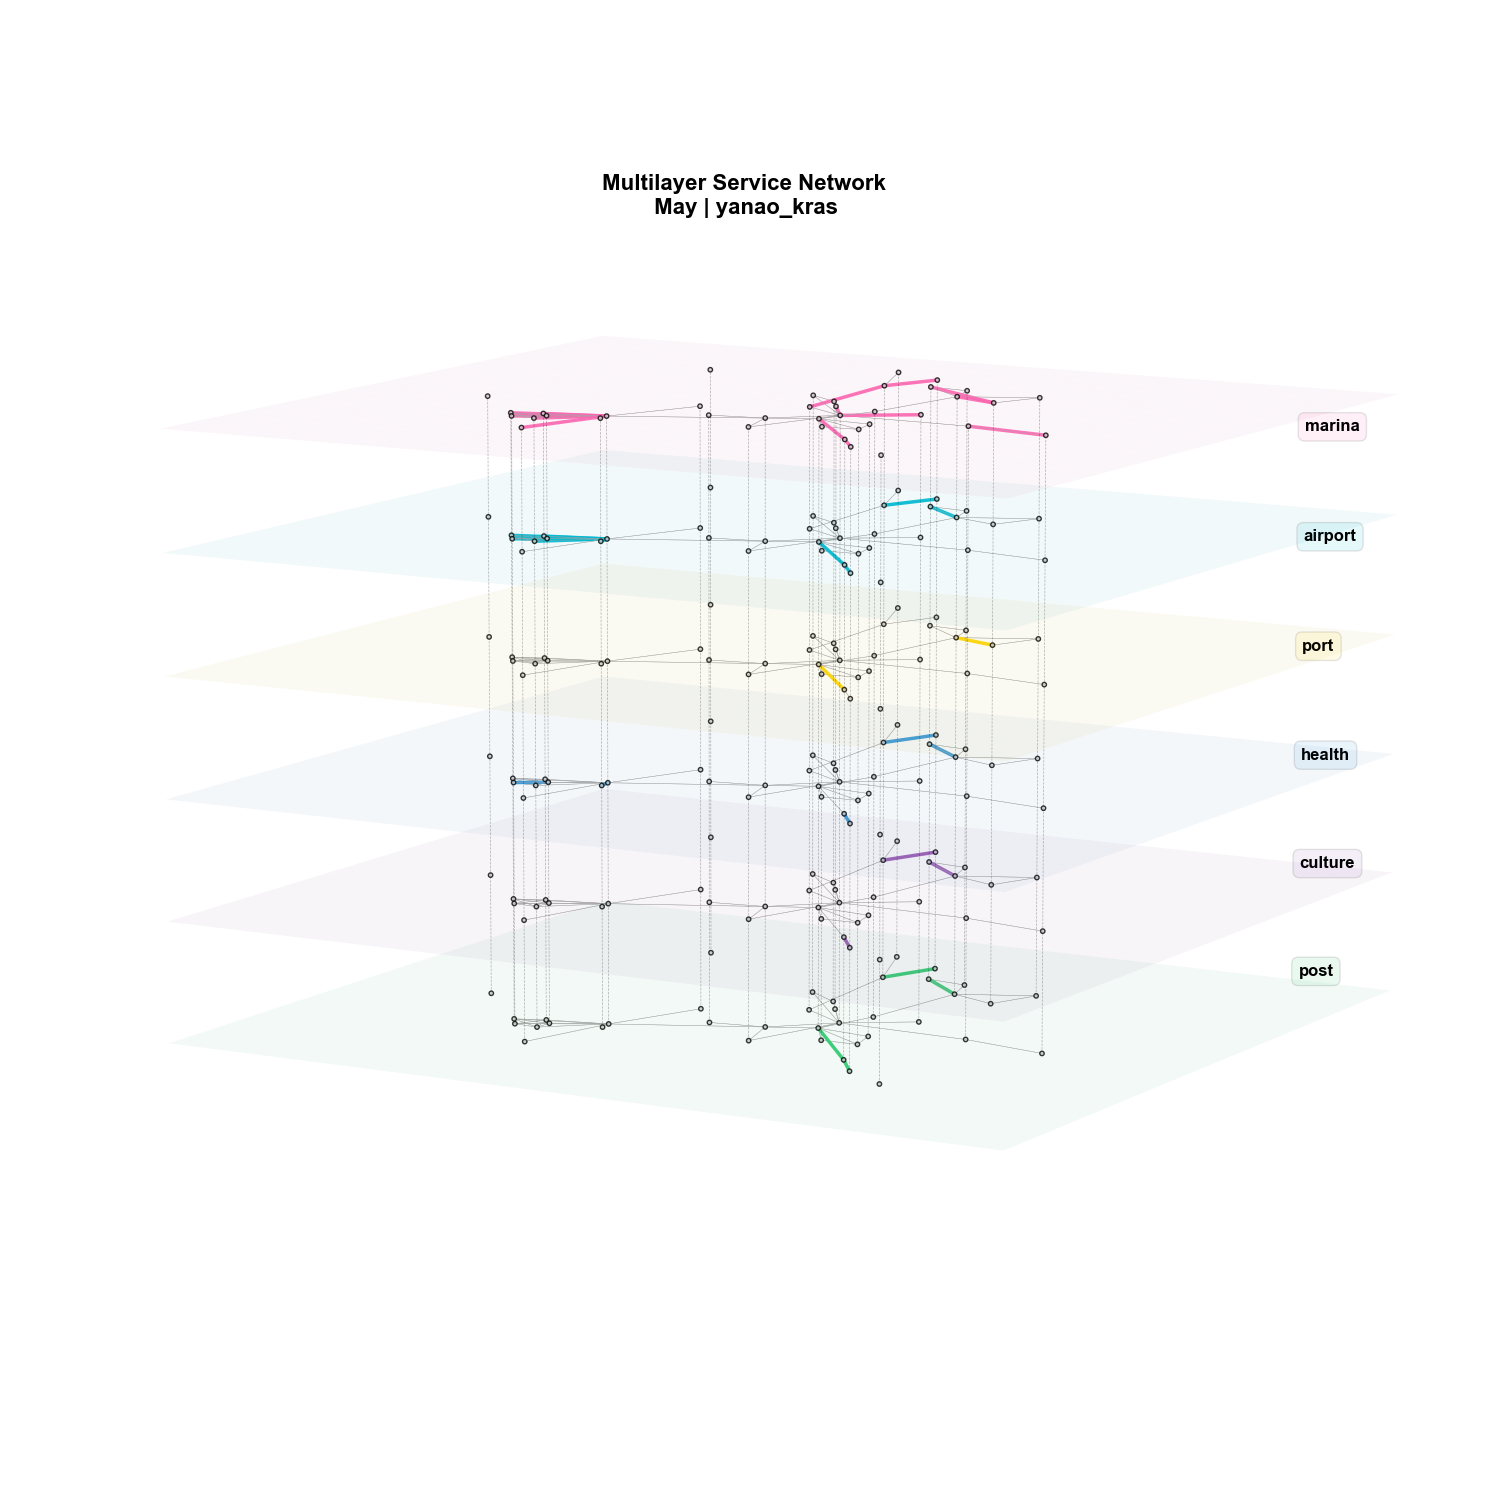

In [ ]:
month = 4

# Example usage:
fig = plot_multilayer_network(
    all_results, SETTL_NAME, service_list, month=month, figsize=(15, 30)
)


# time.sleep(2)  # Pause to ensure the plot is rendered before saving
# plt.savefig(
#     f"../plots/multilayer_network_{SETTL_NAME}_{month_order[month]}.png",
#     bbox_inches="tight",
#     dpi=300,
# )


## 4. Sankey chart

In [ ]:
# for service in service_list:
for service in ["marina"]:
    month_start = 4
    end_month = 10
    graphs = all_results[SETTL_NAME][service]["stats"].graphs[month_start:end_month]
    _ = create_clean_sankey(graphs, service_name=service, month_start=month_start)


Creating Sankey for 6 time periods...
Excluding 21 self-sufficient settlements: ['Nahodka', 'Dikson', 'Karaul', 'Munguj', 'Tazovskij', 'Nosok', 'Antipajuta', 'Ratta', 'Tuhard', 'Vorontsovo', 'Potapovo', 'Dudinka', 'Hantajskoe Ozero', 'Popigaj', 'Novyj Urengoj', 'Tarko-Sale', "Noril'sk", "Krasnosel'kup", 'Gyda', 'Gaz-Sale', 'Hatanga']
Found 17 consumers
T1: 14 assignments, 3 no provider
T2: 17 assignments, 0 no provider
T3: 17 assignments, 0 no provider
T4: 17 assignments, 0 no provider
T5: 17 assignments, 0 no provider
T6: 14 assignments, 3 no provider
Created 55 nodes
Created 102 flows


## 5. Circular flow chart

In [ ]:
month_n = 5
# for service in service_list:
for service in ["marina"]:
    # graphs = all_results[SETTL_NAME][service]["stats"].graphs[month_start:end_month]
    graphs = all_results[SETTL_NAME][service]["stats"].graphs[month_n : month_n + 1]
    for i, g in enumerate(graphs):
        fig = plot_circular_network_sankey_style(
            g,
            service_name=service,
            month_name=month_order[month_start + i],
        )
        fig.show()


## 6. Service coverage map

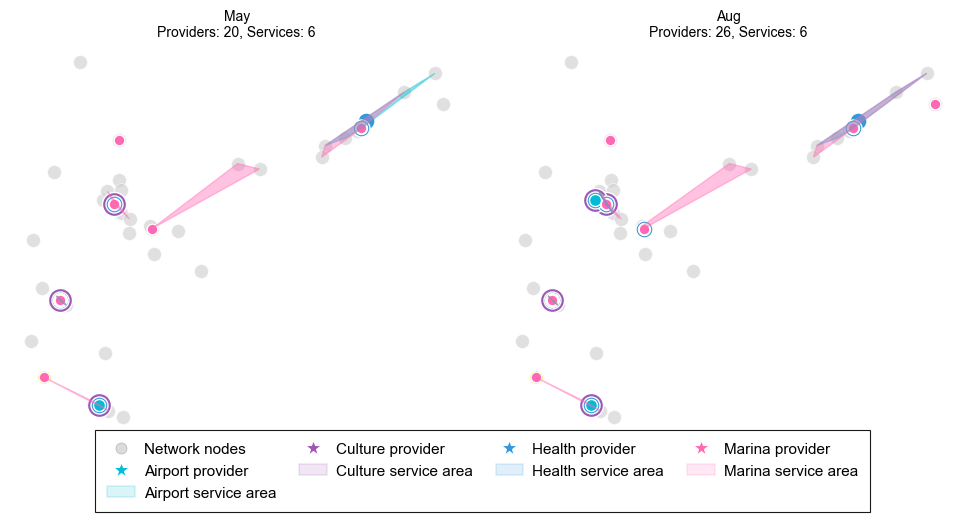

In [ ]:
MONTH_RANGE = range(4, 8, 3)  # May to October (indices 4-9)
results = plot_temporal_service_evolution(all_results, SETTL_NAME, MONTH_RANGE)


## 8. Solver FLP — размещение новых объектов

In [ ]:
"""Импорт солвера FLP"""

solver_path = str(Path.cwd() / "solver_flp" / "src")
if solver_path not in sys.path:
    sys.path.insert(0, solver_path)

from method import genetic_algorithm_main, choose_edges, block_coverage, fitness_plot


In [ ]:
"""Параметры солвера"""

FLP_SERVICE = "health"  # сервис для оптимизации
FLP_MONTH = 0  # месяц (индекс), для которого берём снапшот обеспеченности

# Параметры генетического алгоритма
SERVICE_RADIUS = service_radius_minutes[SETTL_NAME]
population_size = 50
num_generations = 20
num_parents = 10
num_offspring = population_size - num_parents
mutation_rate = 0.7


In [ ]:
"""Подготовка данных: извлекаем provision-результат за выбранный месяц"""

import geopandas as gpd
import pandas as pd
import numpy as np

# Граф за нужный месяц
G_month = all_results[SETTL_NAME][FLP_SERVICE]["stats"].graphs[FLP_MONTH]

# Собираем df_with_demand из атрибутов узлов
node_records = []
for node, data in G_month.nodes(data=True):
    node_records.append(
        {
            "id": node,
            "name": data.get("name", node),
            "population": data.get("population", 0),
            "demand": data.get("demand", 0),
            "demand_within": data.get("demand_within", 0),
            "demand_without": data.get("demand_without", 0),
            f"capacity_{FLP_SERVICE}": data.get(f"capacity_{FLP_SERVICE}", 0),
            "capacity_left": data.get("capacity_left", 0),
            "provision": data.get("provision", 0),
            "geometry": data.get("geometry", None),
        }
    )

df_with_demand = gpd.GeoDataFrame(node_records).set_index("id")
if df_with_demand.geometry.notna().any():
    df_with_demand = df_with_demand.set_geometry("geometry")

print(f"Всего узлов: {len(df_with_demand)}")
print(f"Не обеспечены (provision < 1): {(df_with_demand['provision'] < 1).sum()}")
df_with_demand.head()


Всего узлов: 38
Не обеспечены (provision < 1): 7


,name,population,demand,demand_within,demand_without,capacity_health,capacity_left,provision,geometry
id,,,,,,,,,
Antipajuta,Antipajuta,2685,323.0,323.0,0.0,1200,877.0,1.0,"POLYGON ((8557833.871 10781168.572, 8557829.05..."
Gyda,Gyda,3614,434.0,434.0,0.0,1200,766.0,1.0,"POLYGON ((8738088.346 11365649.121, 8738083.53..."
Nahodka,Nahodka,1305,157.0,157.0,0.0,600,443.0,1.0,"POLYGON ((8634049.15 10364906.955, 8634044.335..."
Bajkalovsk,Bajkalovsk,122,15.0,15.0,0.0,600,585.0,1.0,"POLYGON ((9309922.9 11299045.727, 9309918.085 ..."
Vorontsovo,Vorontsovo,253,31.0,31.0,0.0,600,569.0,1.0,"POLYGON ((9302678.462 11645073.449, 9302673.64..."


In [ ]:
"""Строим матрицу доступности из графа (кратчайшие пути)"""

from scripts.model.provision import create_adjacency_matrix

adj_matrix = create_adjacency_matrix(G_month)

# Оставляем только необеспеченные узлы
uncovered = df_with_demand.copy()
uncovered_ids = uncovered.index.tolist()

acc_matrix_uncovered = adj_matrix.loc[uncovered_ids, uncovered_ids].copy()
acc_matrix_uncovered.reset_index(drop=True, inplace=True)
acc_matrix_uncovered.columns = acc_matrix_uncovered.index

uncovered.reset_index(drop=True, inplace=True)

print(f"Необеспеченных блоков: {len(uncovered)}")


Необеспеченных блоков: 38


In [ ]:
service


'marina'

In [ ]:
uncovered.rename(columns={f"capacity_{FLP_SERVICE}": "capacity"}, inplace=True)


In [ ]:
"""
НИЖЕ НУЖНО ОТДАВАТЬ ПОЛНЫЙ ГДФ (который выше)
"""


100%|██████████| 38/38 [00:00<00:00, 643.32it/s]


Рёбер в графе кандидатов: 43


100%|██████████| 20/20 [00:52<00:00,  2.64s/it]


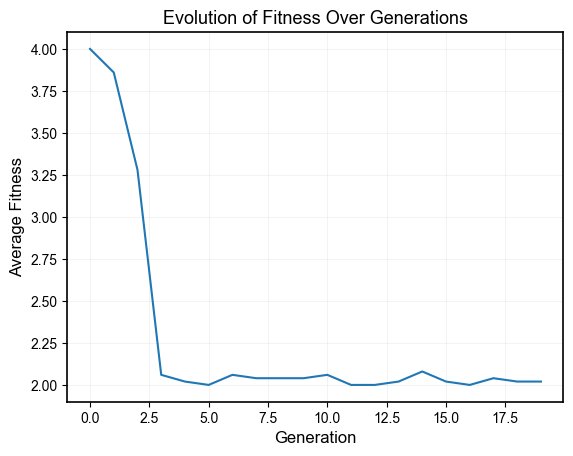

In [ ]:
"""Запуск генетического алгоритма"""

edges_uncovered = choose_edges(
    sim_matrix=acc_matrix_uncovered, service_radius=SERVICE_RADIUS
)
print(f"Рёбер в графе кандидатов: {len(edges_uncovered)}")

best_candidate, fitness_history = genetic_algorithm_main(
    matrix=acc_matrix_uncovered,
    edges=edges_uncovered,
    population_size=population_size,
    num_generations=num_generations,
    df=uncovered,
    service_radius=SERVICE_RADIUS,
    mutation_rate=mutation_rate,
    num_parents=num_parents,
    num_offspring=num_offspring,
    number_res="all",
)

fitness_plot(fitness_history)


In [ ]:
"""Результаты: новые объекты и зоны обслуживания"""

capacities, res_id = block_coverage(
    best_candidate, SERVICE_RADIUS, uncovered, uncovered_ids
)

print("Вместимости новых объектов:", [c for c in capacities if c and c > 0])
print("\nПривязка блоков к новым объектам (id_объекта -> [id_блоков]):")
res_id


Вместимости новых объектов: [50.0, 67.0, 50.0, 60.0]

Привязка блоков к новым объектам (id_объекта -> [id_блоков]):


{'Karaul': ['Bajkalovsk',
  'Vorontsovo',
  'Dudinka',
  'Karaul',
  'Nosok',
  'Volochanka',
  'Tuhard',
  "Ust'-Port",
  'Hantajskoe Ozero',
  'Polikarpovsk',
  'Potapovo'],
 'Novorybnaja': ['Novorybnaja'],
 "Tol'ka": ["Krasnosel'kup",
  'Tarko-Sale',
  'Kikkiakki',
  'Novyj Urengoj',
  "Tol'ka"],
 'Syndassko': ['Syndassko']}